# Gravity removal with rotation matrix

Basic 3D rotations around each axis can be represented by pre-multiplying a column vector by a rotation matrix. If $\phi$ is the roll angle, $\theta$ is the pitch angle, and $\psi$ is the yaw angle, the rotation matrices for roll, pitch and yaw rotations are defined as follows:

$$
R_x(\phi) = \begin{bmatrix}
1 & 0 & 0 \\
0 & \cos\phi & -\sin\phi \\
0 & \sin\phi & \cos\phi
\end{bmatrix}
$$

$$
R_y(\theta) = \begin{bmatrix}
\cos\theta & 0 & \sin\theta \\
0 & 1 & 0 \\
-\sin\theta & 0 & \cos\theta
\end{bmatrix}
$$

$$
R_z(\psi) = \begin{bmatrix}
\cos\psi & -\sin\psi & 0 \\
\sin\psi & \cos\psi & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

These matrices can be combined in different orders to represent a complete rotation in space. The order matters because matrix multiplication is not commutative. They also verify that: $ \bm{R}(\theta)^{-1} = \bm{R}(\theta)^T = \bm{R}(-\theta) $.

For this application, the gravity vector has to be expressed from the world frame into the body frame as follows:

$$
\bm{g_{body}} = \bm{R_{world\rightarrow body}} \cdot \bm{g_{world}}
$$

Keeping the same Euler convention used in the complementary filter, if the body-to-world rotation is written as $\bm{R_{body\rightarrow world}} = \bm{R_z(\psi)} \cdot \bm{R_y(\theta)} \cdot \bm{R_x(\phi)}$, then the world-to-body rotation is its inverse:

$$
\bm{R_{world\rightarrow body}} = \bm{R_{body\rightarrow world}}^{-1} = \bm{R_{body\rightarrow world}}^T = \bm{R_x(\phi)}^T \cdot \bm{R_y(\theta)}^T \cdot \bm{R_z(\psi)}^T = \bm{R_x(-\phi)} \cdot \bm{R_y(-\theta)} \cdot \bm{R_z(-\psi)}
$$

Using $\bm{g_{world}} = [0, 0, g]^T$ and noticing that yaw does not affect gravity compensation because rotations around the gravity axis leave $\bm{g_{world}}$ unchanged, the result is:

$$
\bm{g_{body}} = \begin{bmatrix}
- g\sin\theta \\
g\sin\phi\cos\theta \\
g\cos\phi\cos\theta
\end{bmatrix}
$$

Then it can be subtracted from the accelerometer readings to remove the gravity component:

$$
\bm{a_{body}} = \bm{a_{measured}} - \bm{g_{body}}
$$

To do a sanity check of the gravity removal, it's possible to check the norm of the resulting acceleration vector, which will follow some distribution. In the case of where the device is stationary, the mean of the norm should be close to 0, and the distribution should be normal, with variance due to sensor noise. When there's motion, a right-skewed distribution is probably expected, since taking the norm makes the distribution non-negative even with symmetric movement (concentric and eccentric), and acceleration may be moderate with some occasional bursts.

Sources:
- <https://en.wikipedia.org/wiki/Rotation_matrix>


## Setup

In [29]:
from signal_utils import IMUSampleReader, IMUStationaryChecker
import numpy as np
import matplotlib.pyplot as plt

calibratedStationaryCaptures = [
    "../1-calibration/output/positive-x-up-calibrated.csv",
    "../1-calibration/output/negative-x-up-calibrated.csv",
    "../1-calibration/output/positive-y-up-calibrated.csv",
    "../1-calibration/output/negative-y-up-calibrated.csv",
    "../1-calibration/output/positive-z-up-calibrated.csv",
    "../1-calibration/output/negative-z-up-calibrated.csv",
]

complementaryStationaryCaptures = [
    "../3-orientation/output/positive-x-up-calibrated-complementary.csv",
    "../3-orientation/output/negative-x-up-calibrated-complementary.csv",
    "../3-orientation/output/positive-y-up-calibrated-complementary.csv",
    "../3-orientation/output/negative-y-up-calibrated-complementary.csv",
    "../3-orientation/output/positive-z-up-calibrated-complementary.csv",
    "../3-orientation/output/negative-z-up-calibrated-complementary.csv",
]

simpleRotationsCaptures = [
    "../3-orientation/output/rotation-x-hw-complementary.csv",
    "../3-orientation/output/rotation-y-hw-complementary.csv",
    "../3-orientation/output/rotation-z-hw-complementary.csv",
]

realExerciseCaptures = [
    "../3-orientation/output/dips-1-complementary.csv",
    "../3-orientation/output/dips-2-complementary.csv",
    "../3-orientation/output/dips-3-complementary.csv",
    "../3-orientation/output/pull-ups-1-complementary.csv",
    "../3-orientation/output/pull-ups-2-complementary.csv",
    "../3-orientation/output/pull-ups-3-complementary.csv",
    "../3-orientation/output/90-deg-push-ups-1-complementary.csv",
    "../3-orientation/output/90-deg-push-ups-2-complementary.csv",
]

reader = IMUSampleReader()

stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(calibratedStationaryCaptures)

Accel norms: mean = 9.806204, stdev = 0.040047
 Stationary tol = 0.240281
Gyro norms: stdev = 2.590542
 Stationary tol = 7.771626


In [30]:
def plotGravitySubstractionHistograms(captures):
    cols = 3
    rows = (len(captures) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(5 * cols, 5 * rows))
    fig.suptitle("Gravity-free acceleration norm histograms")

    residualsMemo = {}
    areStationaryMemo = {}

    # Cache residuals and stationary flags compute 97.5th percentile
    residuals = []
    for capture in captures:
        _, a, w, angle = reader.readFiltered(capture)
        residualsMemo[capture] = np.linalg.norm(subtractGravity(a, angle), axis=1)
        areStationaryMemo[capture] = stationaryChecker.areStationarySamples(a, w)
        residuals.append((residualsMemo[capture]))
    globalP975 = np.percentile(np.concatenate(residuals), 97.5)

    for k, capture in enumerate(captures):
        i = k // cols
        j = k % cols

        stationaryResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if isStationary
        ]
        movingResiduals = [
            residual
            for residual, isStationary in zip(
                residualsMemo[capture], areStationaryMemo[capture]
            )
            if not isStationary
        ]

        plotResidualsHistograms(
            axes[i, j],
            stationaryResiduals,
            movingResiduals,
            0,
            globalP975,
            capture,
        )

    # Remove any unused subplots
    for k in range(len(captures), rows * cols):
        fig.delaxes(axes[k // cols, k % cols])

    plt.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


G_WORLD = np.array([0, 0, 9.81])


def subtractGravity(a, angle):
    RBodyWorld = getBodyToWorldRotationMatrices(angle[:, 0], angle[:, 1], angle[:, 2])
    RWorldBody = np.transpose(RBodyWorld, (0, 2, 1))
    return a - RWorldBody @ G_WORLD


def getBodyToWorldRotationMatrices(rolls, pitches, yaws):
    n = len(rolls)

    rollsRad = np.radians(rolls)
    pitchesRad = np.radians(pitches)
    yawsRad = np.radians(yaws)

    Rx = np.zeros((n, 3, 3))
    rollsCos = np.cos(rollsRad)
    rollsSin = np.sin(rollsRad)
    Rx[:, 0, 0] = 1
    Rx[:, 1, 1] = rollsCos
    Rx[:, 1, 2] = -rollsSin
    Rx[:, 2, 1] = rollsSin
    Rx[:, 2, 2] = rollsCos

    Ry = np.zeros((n, 3, 3))
    pitchesCos = np.cos(pitchesRad)
    pitchesSin = np.sin(pitchesRad)
    Ry[:, 0, 0] = pitchesCos
    Ry[:, 0, 2] = pitchesSin
    Ry[:, 1, 1] = 1
    Ry[:, 2, 0] = -pitchesSin
    Ry[:, 2, 2] = pitchesCos

    Rz = np.zeros((n, 3, 3))
    yawsCos = np.cos(yawsRad)
    yawsSin = np.sin(yawsRad)
    Rz[:, 0, 0] = yawsCos
    Rz[:, 0, 1] = -yawsSin
    Rz[:, 1, 0] = yawsSin
    Rz[:, 1, 1] = yawsCos
    Rz[:, 2, 2] = 1

    return Rz @ Ry @ Rx


def plotResidualsHistograms(
    axis, stationaryResiduals, movingResiduals, minVal, maxVal, title
):

    axis.set_title(title, fontsize=8)
    axis.set_xlabel("Residual (m/s^2)")
    axis.set_xlim(minVal, maxVal)
    axis.set_ylabel("Frequency")

    stationaryN = len(stationaryResiduals)
    stationaryMean = np.mean(stationaryResiduals)
    stationaryStd = np.std(stationaryResiduals)
    if stationaryN > 0:

        axis.hist(
            stationaryResiduals, bins=20, color="blue", alpha=0.6, label="Stationary"
        )
        axis.axvline(
            stationaryMean,
            color="blue",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(stationary) = {stationaryMean:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"std(stationary) = {stationaryStd:.3f}",
        )
        axis.plot(
            [],
            [],
            linestyle="",
            label=f"n(stationary) = {stationaryN}",
        )

    movingN = len(movingResiduals)
    movingMean = np.mean(movingResiduals)
    movingStd = np.std(movingResiduals)
    if movingN > 0:

        axis.hist(movingResiduals, bins=20, color="red", alpha=0.6, label="Moving")
        axis.axvline(
            movingMean,
            color="red",
            linestyle="dashed",
            linewidth=2,
            label=f"mean(moving) = {movingMean:.3f}",
        )
        axis.plot([], [], linestyle="", label=f"std(moving) = {movingStd:.3f}")
        axis.plot([], [], linestyle="", label=f"n(moving) = {movingN}")

        if stationaryN > 0:
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean diff = {movingMean - stationaryMean:.3f}",
            )
            axis.plot(
                [],
                [],
                linestyle="",
                label=f"mean ratio = {movingMean / stationaryMean:.3f}",
            )

    axis.legend()
    axis.grid()

## Sanity check: stationary

/home/fedep/Repos/gym-imu/signal/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/fedep/Repos/gym-imu/signal/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/fedep/Repos/gym-imu/signal/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/fedep/Repos/gym-imu/signal/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/fedep/Repos/gym-imu/signal/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


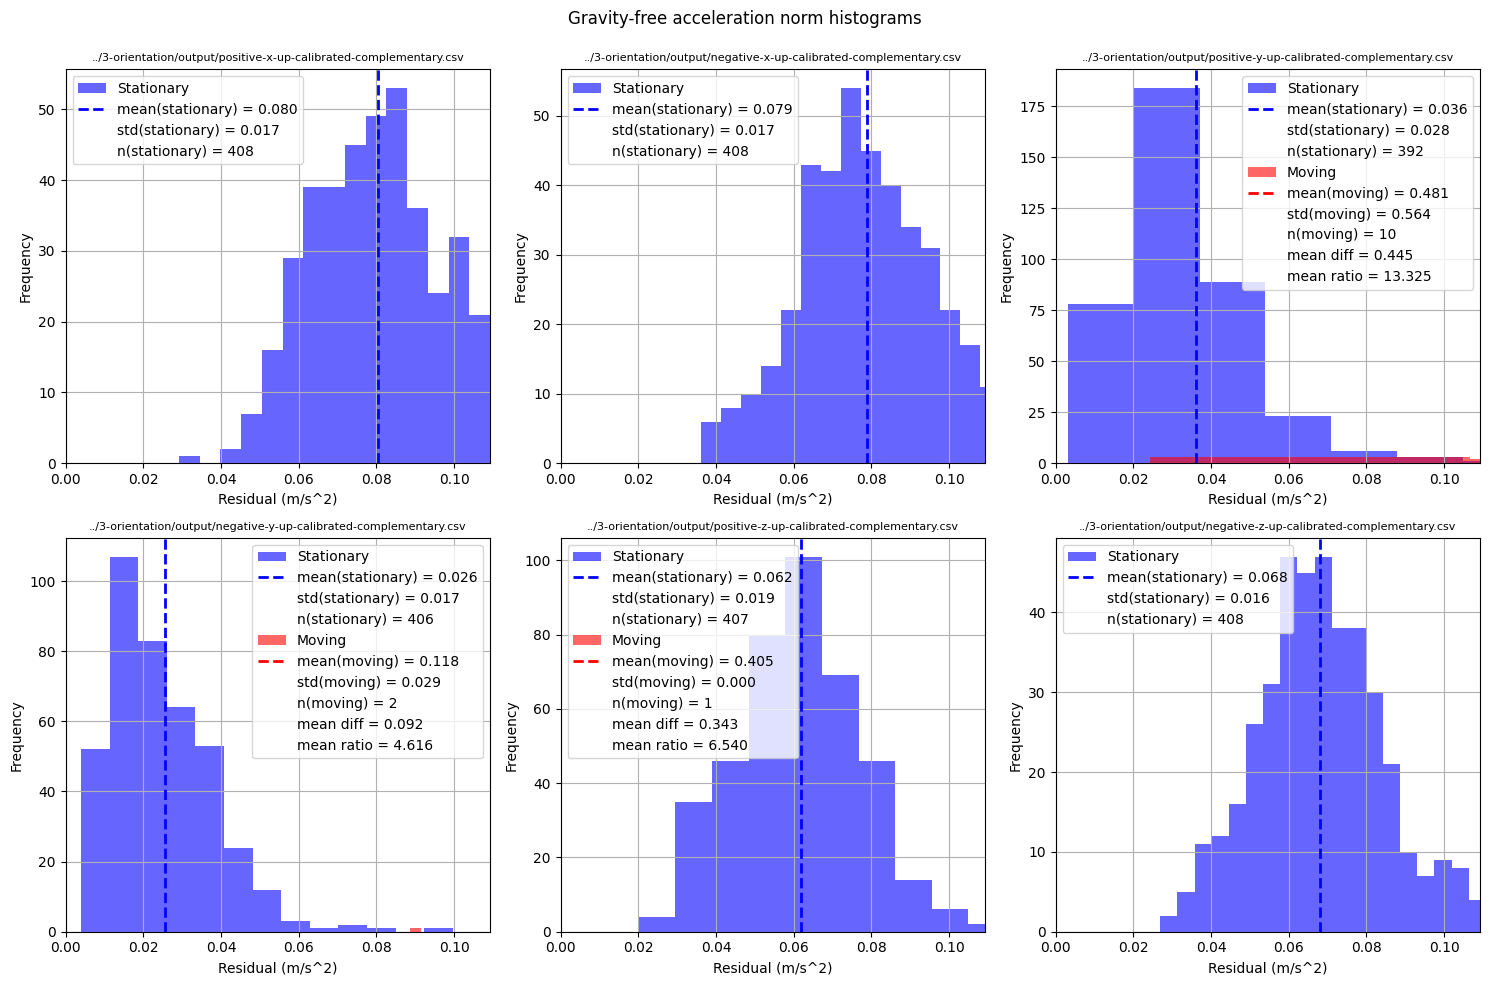

In [31]:
plotGravitySubstractionHistograms(complementaryStationaryCaptures)

## Simple rotations

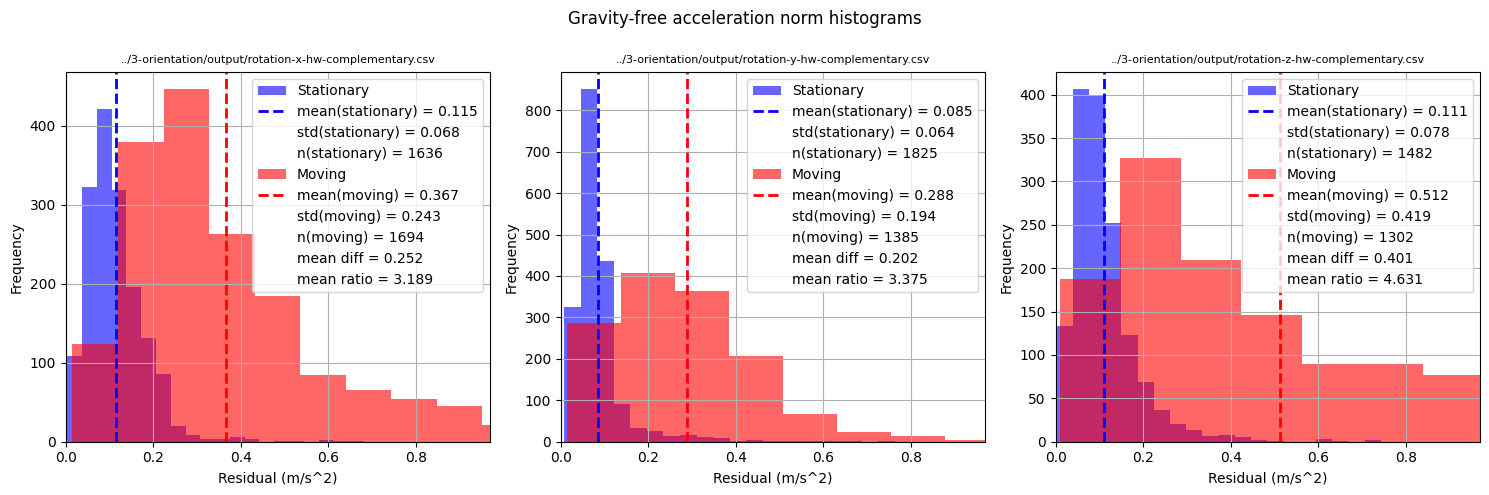

In [32]:
plotGravitySubstractionHistograms(simpleRotationsCaptures)

## Real exercises

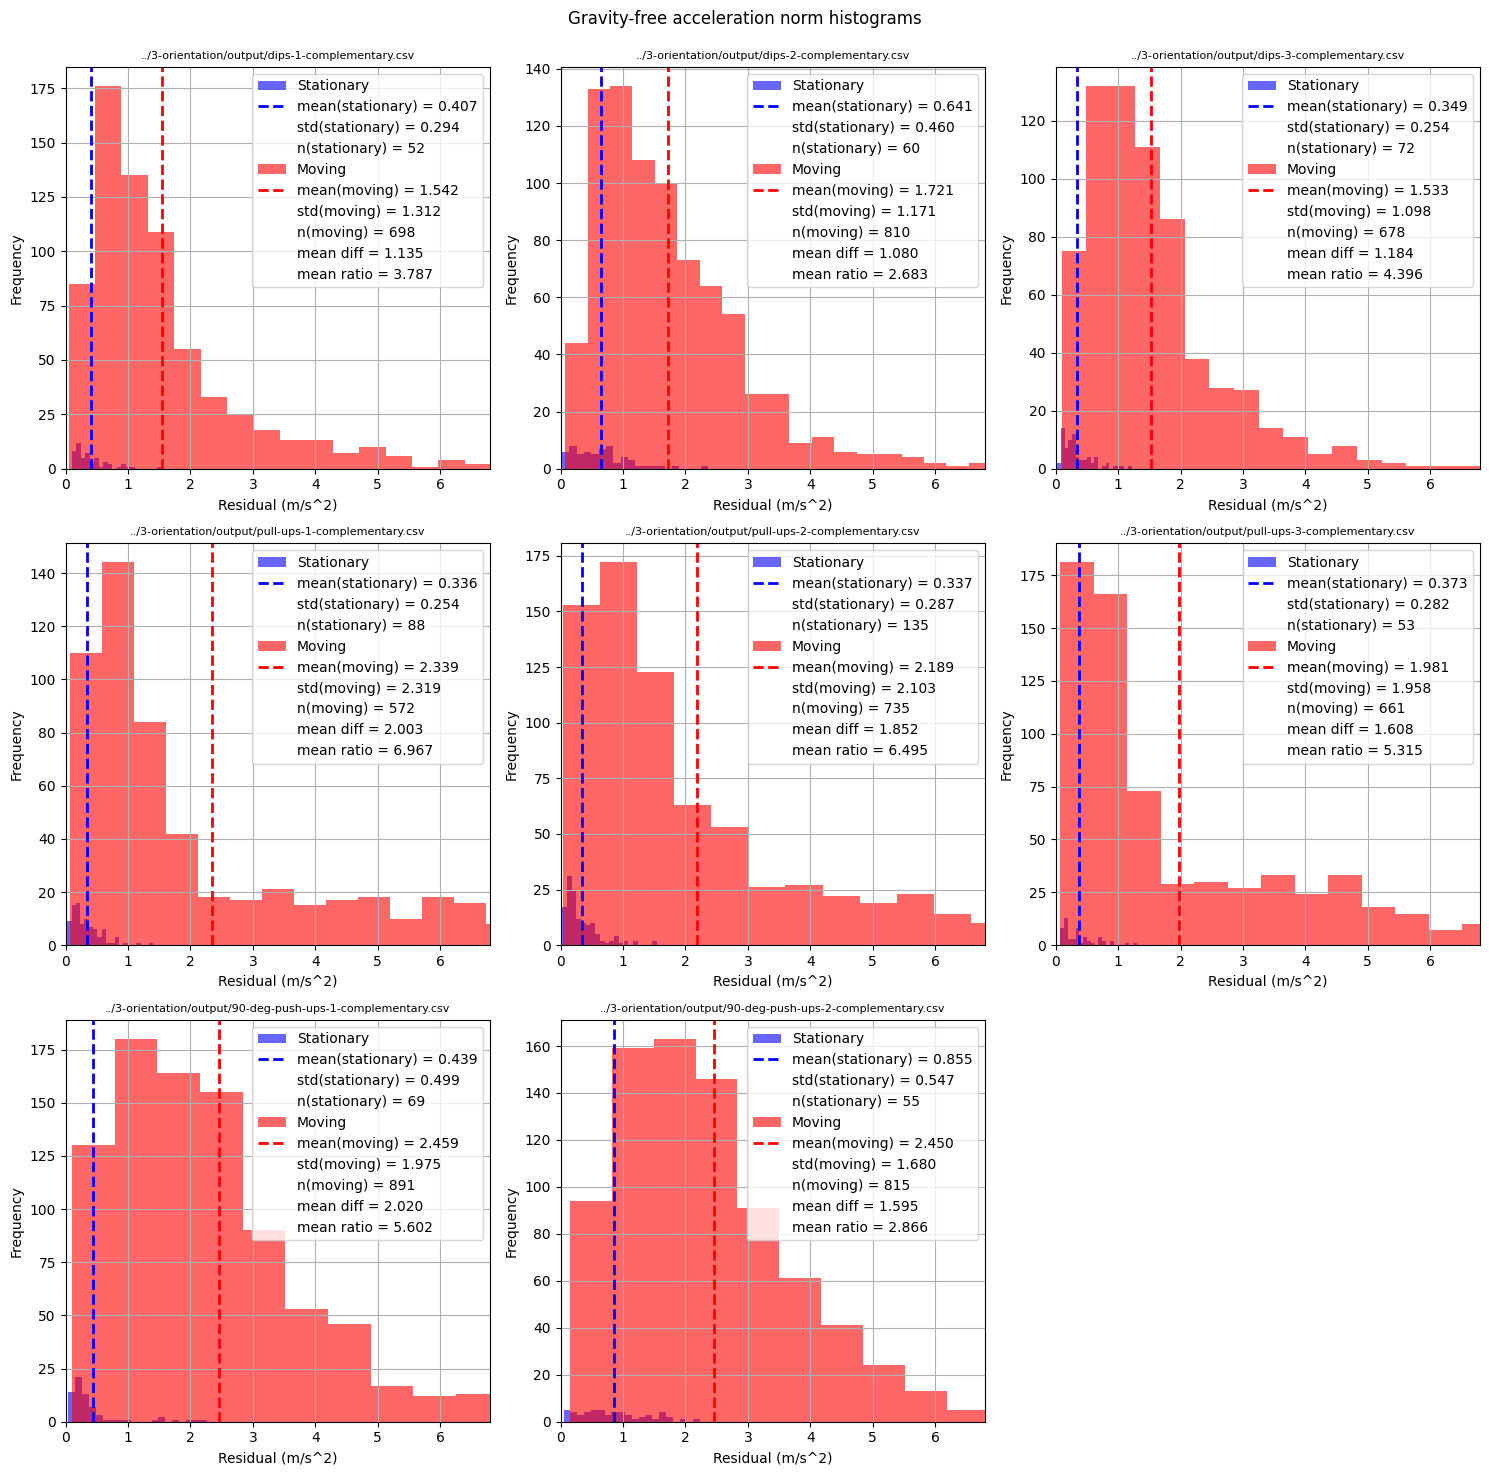

In [33]:
plotGravitySubstractionHistograms(realExerciseCaptures)

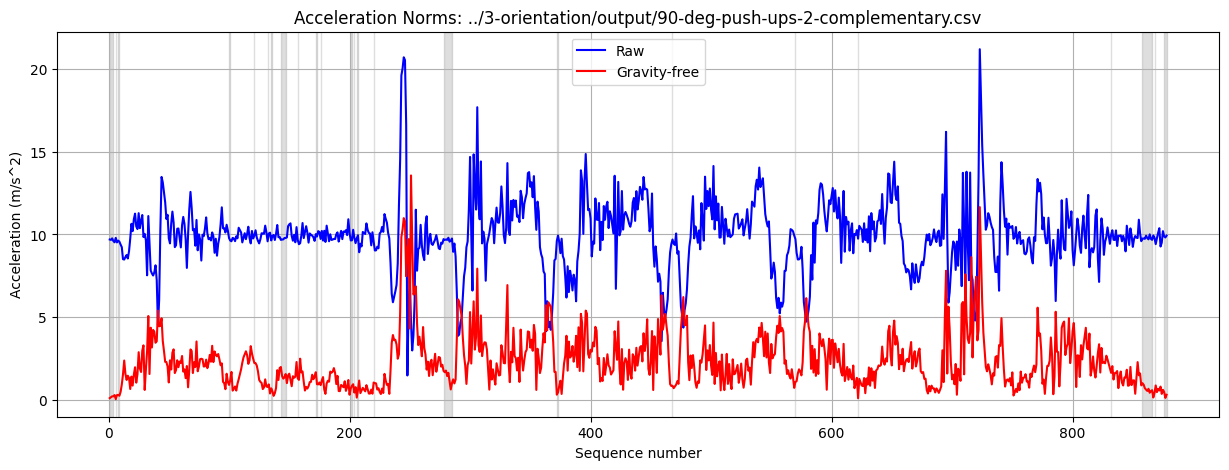

In [34]:
chosenCapture = realExerciseCaptures[7]  # Change index to select different capture
seq, a, w, angle = reader.readFiltered(chosenCapture)
rawAccelNorm = np.linalg.norm(a, axis=1)
gravityFreeAccelNorm = np.linalg.norm(subtractGravity(a, angle), axis=1)
stationaryIntervals = stationaryChecker.findStationaryIntervals(seq, a, w)

fig, axis = plt.subplots(figsize=(15, 5))
axis.plot(seq, rawAccelNorm, label="Raw", color="blue")
axis.plot(seq, gravityFreeAccelNorm, label="Gravity-free", color="red")
axis.set_title(f"Acceleration Norms: {chosenCapture}")
axis.set_xlabel("Sequence number")
axis.set_ylabel("Acceleration (m/s^2)")
for lower, upper in stationaryIntervals:
    axis.axvspan(lower, upper, color="tab:gray", alpha=0.25, zorder=0)
axis.legend()
axis.grid()
plt.show()